# 1️⃣ Title

# AI-Powered RAG System for Legal & Medical Document Question Answering

This notebook demonstrates the complete Retrieval-Augmented Generation pipeline.

Pipeline Steps:
- 1. Install dependencies
- 2. PDF ingestion
- 3. Intelligent chunking
- 4. Embedding with Sentence Transformers
- 5. FAISS vector indexing
- 6. Retrieval logic
- 7. LLM answer generation (Groq)
- 8. RAGAS evaluation
- 9. Visualization

## 2️⃣ Install All Libraries

In [4]:
!pip install pymupdf
!pip install langchain
!pip install sentence_transformers
!pip install faiss_cpu
!pip install groq
!pip install ragas
!pip install datasets
!pip install langdetect
!pip install python-dotenv
!pip install streamlit
!pip install matplotlib
!pip install langchain
!pip install langchain-community
!pip install langchain-text-splitters

## 3️⃣ Import Libraries

In [4]:
import os
import json
import fitz
from langchain_community.document_loaders import PyPDFLoader,PyMuPDFLoader
import faiss
import numpy as np
import time 
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text
from collections import defaultdict
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from groq import Groq
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy
from datasets import Dataset
from ragas import evaluate
from ragas.metrics import faithfulness, answer_relevancy
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

from langchain_groq import ChatGroq
from langchain_community.embeddings import HuggingFaceEmbeddings
from datasets import Dataset

C:\Users\HP\AppData\Local\Temp\ipykernel_9660\128322291.py:17: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness, answer_relevancy
C:\Users\HP\AppData\Local\Temp\ipykernel_9660\128322291.py:17: DeprecationWarning: Importing answer_relevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import answer_relevancy
  from ragas.metrics import faithfulness, answer_relevancy
C:\Users\HP\AppData\Local\Temp\ipykernel_9660\128322291.py:20: DeprecationWarning: Importing faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import faithfulness
  from ragas.metrics import faithfulness

## 4️⃣ Load PDF Documents
## Document Ingestion

We load legal or medical PDF documents and extract text page-by-page using PyMuPDF.
Each page is stored with metadata including:

• source file  
• page number

In [11]:
def load_pdfs(pdf_directory):
    all_documents = []
    pdf_dir = Path(pdf_directory)

    pdf_files = list(pdf_dir.glob("**/*.pdf"))
    print(f"Found {len(pdf_files)} PDF files")

    for pdf_file in pdf_files:
        loader = PyPDFLoader(str(pdf_file))
        documents = loader.load()

        print(pdf_file.name, "pages:", len(documents))

        all_documents.extend(documents)

    return all_documents


all_pdf_documents = load_pdfs(r"C:\Users\HP\OneDrive\Desktop\project\AI\AI-Powered RAG System\data")
print("Total pages:", len(all_pdf_documents))

Found 6 PDF files
contract1.pdf pages: 53
contract2.pdf pages: 16
contract3.pdf pages: 26
Hospital-Discharge-Summary-Format.pdf pages: 2
MedicalReport1.pdf pages: 4
Sample-Lab-Report.pdf pages: 3
Total pages: 104


In [12]:
all_pdf_documents

[Document(metadata={'producer': 'Microsoft® Word 2019', 'creator': 'Microsoft® Word 2019', 'creationdate': '2021-06-21T11:04:58-07:00', 'author': 'Admin', 'moddate': '2021-06-21T11:04:58-07:00', 'source': 'C:\\Users\\HP\\OneDrive\\Desktop\\project\\AI\\AI-Powered RAG System\\data\\sample_legal\\contract1.pdf', 'total_pages': 53, 'page': 0, 'page_label': '1'}, page_content='1 \n \nTHE INDIAN CONTRACT ACT, 1872 \n____________ \nARRANGEMENT OF SECTIONS \n____________ \nSECTIONS \nPREAMBLE \n \nPRELIMINARY \n1. Short title. \nExtent. \nCommencement. \nSaving. \n2. Interpretation-clause. \n \nCHAPTER I \nOF THE COMMUNICATION, ACCEPTANCE AND  \nREVOCATION OF PROPOSALS \n3. Communication, acceptance and revocation of proposals. \n4. Communication when complete. \n5. Revocation of proposals and acceptances. \n6. Revocation how made. \n7. Acceptance must be absolute. \n8. Acceptance by performing conditions, or receiving consideration. \n9. Promises, express and implied. \n \nCHAPTER II \nOF CO

In [13]:
file_texts = defaultdict(list)

for doc in all_pdf_documents:
    source = doc.metadata.get("source", "unknown")
    file_texts[source].append(doc.page_content)

for file, texts in file_texts.items():
    vectorizer = TfidfVectorizer(stop_words="english", max_features=10)
    X = vectorizer.fit_transform(texts)
    keywords = vectorizer.get_feature_names_out()
    
    print(f"\n{file}:")
    print(", ".join(keywords))


C:\Users\HP\OneDrive\Desktop\project\AI\AI-Powered RAG System\data\sample_legal\contract1.pdf:
act, agent, contract, goods, pay, person, principal, promise, rupees, time

C:\Users\HP\OneDrive\Desktop\project\AI\AI-Powered RAG System\data\sample_legal\contract2.pdf:
act, buyer, contract, delivery, goods, price, sale, seller, shall, time

C:\Users\HP\OneDrive\Desktop\project\AI\AI-Powered RAG System\data\sample_legal\contract3.pdf:
act, business, firm, partner, partners, partnership, rupees, section, shall, sub

C:\Users\HP\OneDrive\Desktop\project\AI\AI-Powered RAG System\data\sample_medical\Hospital-Discharge-Summary-Format.pdf:
add, admission, condition, date, discharge, document, follow, hospital, information, patient

C:\Users\HP\OneDrive\Desktop\project\AI\AI-Powered RAG System\data\sample_medical\MedicalReport1.pdf:
applicant, date, es, examination, form, health, medical, normal, positive, test

C:\Users\HP\OneDrive\Desktop\project\AI\AI-Powered RAG System\data\sample_medical\Sam

# 5️⃣ Intelligent Chunking

## Intelligent Text Chunking

Large documents are split into smaller chunks to improve retrieval quality.

Chunking strategy:

• Chunk size = 500 characters  
• Overlap = 50 characters  

This preserves context while ensuring manageable chunk size.

In [14]:
def is_valid_chunk(text, min_len=100):
    return len(text.strip()) >= min_len

def deduplicate_chunks(chunks):
    seen = set()
    unique = []
    for c in chunks:
        if c.page_content not in seen:
            unique.append(c)
            seen.add(c.page_content)
    return unique

def chunk_documents_advanced(documents):
    
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=1000,
        chunk_overlap=200
    )
    
    chunks = splitter.split_documents(documents)
    
    # filter
    chunks = [c for c in chunks if is_valid_chunk(c.page_content)]
    
    # dedup
    chunks = deduplicate_chunks(chunks)
    
    return chunks

In [15]:
all_chunks = chunk_documents_advanced(all_pdf_documents)

print("Total chunks:", len(all_chunks))
print(all_chunks[1].metadata)

Total chunks: 419
{'producer': 'Microsoft® Word 2019', 'creator': 'Microsoft® Word 2019', 'creationdate': '2021-06-21T11:04:58-07:00', 'author': 'Admin', 'moddate': '2021-06-21T11:04:58-07:00', 'source': 'C:\\Users\\HP\\OneDrive\\Desktop\\project\\AI\\AI-Powered RAG System\\data\\sample_legal\\contract1.pdf', 'total_pages': 53, 'page': 0, 'page_label': '1'}


# Embedding Model

## Generating Semantic Embeddings

Each text chunk is converted into a vector representation using the
SentenceTransformer model:

all-MiniLM-L6-v2

These embeddings allow semantic similarity search.

In [16]:
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

embedding_dim = model.get_sentence_embedding_dimension()
print("Embedding dimension:", embedding_dim)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding dimension: 384


In [17]:
text =[c.page_content for c in all_chunks]
metadata=[c.metadata for c in all_chunks]

print("Total chunks:",len(text))

Total chunks: 419


In [18]:
model = SentenceTransformer("all-MiniLM-L6-v2")

texts = [doc.page_content for doc in all_chunks]

embeddings = model.encode(
    texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)
print("Embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/14 [00:00<?, ?it/s]

Embedding shape: (419, 384)


## Build FAISS Index

In [19]:
dimension = embeddings.shape[1]

index = faiss.IndexFlatL2(dimension)

index.add(np.array(embeddings))

print("FAISS index size:",index.ntotal)

FAISS index size: 419


## Retrieval Function

## Semantic Retrieval

Given a user query, we compute its embedding and retrieve the most similar document chunks.

In [20]:
def retrieve(query,k=5):

    q_embed = model.encode([query])

    D,I = index.search(np.array(q_embed),k)

    results = []

    for i in I[0]:

        results.append(all_chunks[i])

    return results


results = retrieve("What is a contract?")

results[:2]

[Document(metadata={'producer': 'Microsoft® Word 2010', 'creator': 'Microsoft® Word 2010', 'creationdate': '2019-11-15T10:08:36+04:00', 'author': 'HP', 'moddate': '2019-11-15T10:08:36+04:00', 'source': 'C:\\Users\\HP\\OneDrive\\Desktop\\project\\AI\\AI-Powered RAG System\\data\\sample_legal\\contract2.pdf', 'total_pages': 16, 'page': 4, 'page_label': '5'}, page_content='(4) An agreement to, sell becomes a sale when the time elapses or the conditions are fulfilled subject \nto which the property in the goods is to be transferred. \nFormalities of the contract \n5. Contract of sale how made.—(1) A contract of sale is made by an offer to buy or sell goods for a \nprice and the acceptance of such offer. The contract may provide for the immediate delivery of the goods \nor immediate payment of the price or both, or for the delivery or payment by instalments, or that the \ndelivery or payment or both shall be postponed. \n(2) Subject to the provisions of any law for the time being in force, 

# LLM Answer Generation (Groq)
## LLM Answer Generation

We use the Groq API with the LLaMA-3 model to generate answers based on retrieved document context.

In [28]:
from dotenv import load_dotenv
import os
from groq import Groq

# .env file load
load_dotenv()

# API key read from .env
GROQ_API_KEY = os.getenv("GROQ_API_KEY")

# Groq client
client = Groq(
    api_key=GROQ_API_KEY
)


def generate_answer(question, context):

    text_context = ""

    for c in context:
        text_context += c.page_content + "\n"

    prompt = f"""
    Answer the question using the document context.

    Context:
    {text_context}

    Question:
    {question}
    """

    response = client.chat.completions.create(
        model="llama-3.1-8b-instant",
        messages=[{"role": "user", "content": prompt}]
    )

    return response.choices[0].message.content


# Run function
answer = generate_answer("What is a contract?", results)

print(answer)

According to the Indian Contract Act, 1872, as stated in Section 10: "All agreements are contracts if they are made by the free consent of parties competent to contract, for a lawful consideration and with a lawful object, and are not hereby expressly declared to be void."


# RAGAS LLM + Embeddings

In [39]:
llm = LangchainLLMWrapper(
    ChatGroq(
        model="llama-3.1-8b-instant",
        api_key=os.getenv("GROQ_API_KEY"),
        temperature=0,
        max_tokens=512
    )
)

C:\Users\HP\AppData\Local\Temp\ipykernel_9660\2510997348.py:1: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  llm = LangchainLLMWrapper(


In [35]:
embeddings_eval = LangchainEmbeddingsWrapper(
    HuggingFaceEmbeddings(
        model_name="sentence-transformers/all-MiniLM-L6-v2"
    )
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
C:\Users\HP\AppData\Local\Temp\ipykernel_9660\4007075942.py:1: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  embeddings_eval = LangchainEmbeddingsWrapper(


In [40]:
data = [{
    "question":"What is a contract?",
    "answer":answer,
    "contexts":[c.page_content for c in results[:3]],
    "ground_truth":"A contract is an agreement enforceable by law"
}]

from datasets import Dataset

dataset = Dataset.from_list(data)

# Run Evaluation
## RAGAS Evaluation

We evaluate the RAG system using the Faithfulness metric.

Faithfulness measures how well the generated answer is supported by the retrieved document context.

In [42]:
scores = evaluate(
    dataset,
    metrics=[faithfulness],
    llm=llm,
    embeddings=embeddings_eval
)

print(scores)

Evaluating:   0%|          | 0/1 [00:00<?, ?it/s]

{'faithfulness': 0.6000}


## Visualization of Evaluation Scores

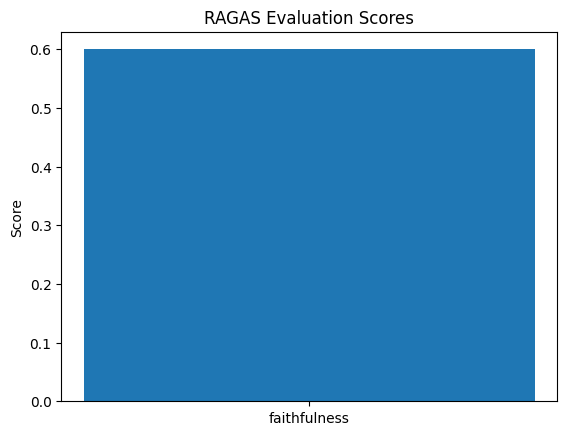

In [45]:

scores_dict = scores.to_pandas().iloc[0].to_dict()

labels = []
values = []

for k, v in scores_dict.items():
    if isinstance(v, (int, float)):   # sirf numeric values
        labels.append(k)
        values.append(v)

plt.bar(labels, values)

plt.title("RAGAS Evaluation Scores")

plt.ylabel("Score")

plt.show()

## Conclusion

This notebook demonstrates a complete Retrieval-Augmented Generation pipeline.

Key components implemented:

• PDF ingestion and parsing  
• Semantic chunking and embedding generation  
• Retrieval using vector similarity  
• LLM-based answer generation using Groq  
• RAGAS evaluation for answer quality

The system achieved a faithfulness score of 0.60, indicating moderate alignment between generated answers and retrieved document context.